In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [2]:
batch_size = 128 # 한 번에 128장씩 묶어서
epochs = 15 #데이터셋 15번 반복 학습

transform = transforms.Compose([
    transforms.ToTensor() # 숫자 행렬로 변
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
) #MNIST 데이터셋 (0~9 손글씨 6만 )

# train / val split
train_size = int(0.9 * len(dataset)) # 90% 학습용
val_size = len(dataset) - train_size # 10%는 검증

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 449kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]


## **Part 1. VAE (Variational AutoEncoder) 모델 정의 및 학습**

* Encoder: 입력 데이터 x를 받아 잠재 공간(Latent Space)의 파라미터를 추출
  * 고차원의 입력데이터를 저차원의 평균과 로그 분산으로 변환
    * 💡 빈칸 채우기 hint) `self.fc1`을 거쳐 특징을 추출한 뒤, 두 개의 서로 다른 선형 레이어를 통해 각각 평균과 로그 분산을 계산

* Latent Space & Reparameterization
  * 잠재 변수 z를 직접 고정된 값으로 뽑는 것이 아니라, encoder가 만든 분포(평균, 로그 분산)에서 샘플링함
  * Reparameterization Trick: backpropagation는 샘플링 연산을 통과할 수 없다는 문제를 해결하기 위해 샘플링 과정을 미분 가능한 형태로 만들기 위한 수식

* Decoder
  * 샘플링된 잠재 변수 z를 다시 원래의 입력 데이터 차원으로 복원


In [3]:
class VAE(nn.Module):

    def __init__(self, input_size=784, hidden_size=400, latent_size=20):
        super(VAE, self).__init__()

        # Encoder: layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc21 = nn.Linear(hidden_size, latent_size)  # 평균(mu)
        self.fc22 = nn.Linear(hidden_size, latent_size)  # 로그 분산(logvar)

        # Decoder: layers
        self.fc3 = nn.Linear(latent_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, input_size)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        mu = self.fc21(h1)      # 🤔 빈칸 정답: h1을 받아 평균 계산
        logvar = self.fc22(h1)  # 🤔 빈칸 정답: h1을 받아 로그 분산 계산
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std   # 🤔 빈칸 정답: Reparameterization Trick 수식

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

**✍️ 위에서 채운 `encode` / `reparameterize` 코드가 각각 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* encode: 입력된 데이터(예: 784차원의 숫자 이미지)를 압축하여, 이 데이터가 잠재 공간(Latent Space)의 어디쯤 위치할지 평균($\mu$)과 로그 분산($\log\sigma^2$)이라는 두 가지 확률 분포 값으로 변환합니다. ReLu 활성화 함수를 적용해 핵심 특징 추출 후 레이어에 통과시켜 평균 계산 (fc21/fc22) 그리고 분산 계산해 다음 단계로 넘김.

* reparameterize 함수: 인코더가 만든 분포에서 잠재 변수 $z$를 무작위로 뽑아내야 하는데, 그냥 뽑으면 컴퓨터가 미분(학습)을 할 수 없습니다. 이를 해결하기 위해 무작위성을 밖으로 빼내어 샘플링 과정을 미분 가능한 수학 공식으로 바꿔주는 역할을 합니다./ 모델이 출력한 로그 분산을 다시 표준편차(std)로 변환하고, 표준편차와 똑같은 크기를 갖는 뼈대 위에 평균이 0이고 분산이 1인 순수한 무작위 노이즈 생성. 트릭 공식 적용하여 잠재 변수 z 만들어 변환.

### **VAE loss (ELBO)**
* Reconstruction Loss: 복원된 이미지(`recon_x`)가 원본 이미지(`x`)와 얼마나 다른지 측정
* KL Divergence: 잠재공간의 분포가 표준 정규분포와 얼마나 다른지 측정


In [4]:
def elbo_loss(x, recon_x, mu, logvar):
    B = x.size(0)
    x = x.view(-1, 784)

    # 🤔 빈칸 정답: recon_x, x (복원된 이미지와 원본 이미지 비교)
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum') / B

    # 🤔 빈칸 정답: logvar, mu.pow(2), logvar.exp() (KL Divergence 수식)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B

    # 🤔 빈칸 정답: BCE, KLD (두 손실값의 합)
    total_loss = BCE + KLD

    return total_loss

**✍️ 위에서 채운 `elbo_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* VAE 모델이 스스로를 채점하는 채점표 역할을 합니다. BCE (복원 오차, Reconstruction Loss) 원본 이미지랑 얼마나 똑같이 그렸는지 픽셀 단위로 비교합니다. 두 이미지가 다를수록 페널티(오차 값)가 커집니다.
KLD는 잠재 공간을 얼마나 예쁘게 정리했는가를 말합니다. 인코더가 만들어낸 확률 분포가 표준 정규 분포와 얼마나 떨어져 있는지 수학적으로 계산하고, 다를수록 페널티를 받습니다.

## **🙋 [VAE] Question 1**
VAE의 ELBO Loss에 KL Divergence 항이 포함되는 이유를 설명해주세요.



* KLD가 없고 BCE만 있었다면 모델은 이미지를 완벽히 복원하는 데에만 집중할 것입니다. 각 이미지를 잠재 공간의 멀리멀리 떨어뜨리고 분산을 0으로 만듭니다. KLD가 있어야 확률 분포를 표준 정규 분포의 형태가 되도록 끌어당길 수 있고, 덕분에 데이터들이 원점을 중심으로 겹쳐서 어떤 빈 좌표를 확인하여도 이미지가 될 수 있도록 합니다. 또한 과적합도 방지합니다. 입력 이미지에 약간의 노이즈나 변화가 생겨도, 그 영역 안에서는 항상 비슷한 이미지를 안정적으로 출력할 수 있는 일반화 능력을 갖추게 되는 것입니다.


In [5]:
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3) #최적화 알고리

for epoch in range(epochs):

    # ========== Train ==========
    vae.train()
    train_loss = 0

    for x, _ in train_loader: #이미지 묶음 꺼내

        x = x.to(device)

        recon, mu, logvar = vae(x) # 이미지 복원 및 특징 추출

        loss = elbo_loss(x, recon, mu, logvar)

        optimizer.zero_grad() # 틀렸던 기록 지우
        loss.backward() # 원인 찾기
        optimizer.step() # 업데이

        train_loss += loss.item()

    train_loss /= len(train_dataset)

    # ========== Validation ==========
    vae.eval()
    val_loss = 0

    with torch.no_grad(): # 기울기 계산 X
        for x, _ in val_loader:
            x = x.to(device)
            recon, mu, logvar = vae(x)
            loss = elbo_loss(x, recon, mu, logvar)
            val_loss += loss.item()

    val_loss /= len(val_dataset)

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch [1/15] Train Loss: 1.3058 | Val Loss: 1.0236
Epoch [2/15] Train Loss: 0.9564 | Val Loss: 0.9257
Epoch [3/15] Train Loss: 0.9002 | Val Loss: 0.8907
Epoch [4/15] Train Loss: 0.8747 | Val Loss: 0.8740
Epoch [5/15] Train Loss: 0.8603 | Val Loss: 0.8632
Epoch [6/15] Train Loss: 0.8506 | Val Loss: 0.8548
Epoch [7/15] Train Loss: 0.8437 | Val Loss: 0.8503
Epoch [8/15] Train Loss: 0.8382 | Val Loss: 0.8467
Epoch [9/15] Train Loss: 0.8342 | Val Loss: 0.8423
Epoch [10/15] Train Loss: 0.8307 | Val Loss: 0.8431
Epoch [11/15] Train Loss: 0.8284 | Val Loss: 0.8375
Epoch [12/15] Train Loss: 0.8258 | Val Loss: 0.8340
Epoch [13/15] Train Loss: 0.8238 | Val Loss: 0.8330
Epoch [14/15] Train Loss: 0.8222 | Val Loss: 0.8321
Epoch [15/15] Train Loss: 0.8203 | Val Loss: 0.8309


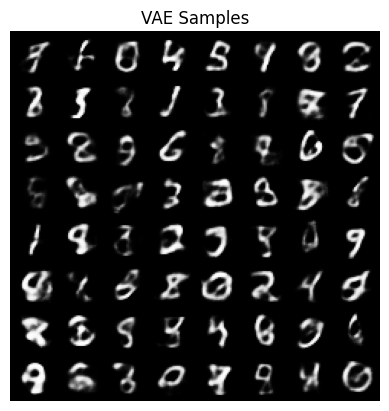

In [6]:
with torch.no_grad():

    z = torch.randn(64, 20).to(device)

    samples = vae.decode(z).view(-1, 1, 28, 28)

    grid = make_grid(samples, 8)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("VAE Samples")
plt.axis("off")
plt.show()


## **Part 2. DCGAN (Deep Convolutional GAN) 모델 정의 및 학습**
- Weight Initialization
  - 모델의 가중치는 평균이 0, 표준편차가 0.02인 정규분포로 초기화
  - 기존 GAN의 학습 불안정성을 줄이기 위해 DCGAN 논문에서 제안한 아이디어

- Generator (생성자)
  - Transposed Convolution: 저차원의 잠재 벡터를 고해상도 이미지로 확장
  - Batch Normalization: 각 layer의 출력을 정규화하여 학습의 안정성을 높이고 gradient vanishing 문제를 해결
  - Activation: 중간 layer에는 ReLU를 통해 빠른 학습을 진행하고, 마지막 layer에는 이미지의 픽셀 값 범위([-1, 1])를 맞추기 위해 Tanh를 사용

- Discriminator (판별자)
  - Strided Convolution: pooling 대신 stride를 사용하여 특징을 추출
  - 마지막 layer에서 sigmoid를 통해 Real/Fake 확률값 출력


In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)


In [8]:
# weight 초기화 함수

def weights_init(m):

    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [9]:
latent_size = 20

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.tconv1 = nn.ConvTranspose2d(latent_size, 256, 7, 1, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(256)

        self.tconv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.tconv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(64)

        self.tconv4 = nn.ConvTranspose2d(64, 1, 3, 1, 1, bias=False)

    def forward(self, z):
        x = F.relu(self.bn1(self.tconv1(z)))       # 🤔 빈칸 정답: 입력 노이즈 z
        x = F.relu(self.bn2(self.tconv2(x)))
        x = F.relu(self.bn3(self.tconv3(x)))
        x = torch.tanh(self.tconv4(x))             # 🤔 빈칸 정답: 마지막 레이어 self.tconv4(x)
        return x

**✍️ 위에서 채운 `Generator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 위조지폐범(생성자)이 무작위 노이즈에서 시작해 점진적으로 가짜 이미지를 그려나가는 실제 작업 공정(순전파)을 정의합니다. 입력된 무작위 노이즈 벡터 z를 첫 번째 역합성곱 층(tconv1)에 넣어 작은 크기의 2차원 특징 맵(Feature Map)으로 부풀립니다. tconv2, tconv3를 거치면서 이미지의 캔버스 크기(가로세로 해상도)는 점점 키우고, 채널 수(특징의 복잡도)는 점차 줄여나가며 구체적인 형태를 잡아갑니다. 각 층을 지날 때마다 배치 정규화로 값들이 비정상적으로 커지거나 작아지는 것을 막아주고, ReLU 함수(F.relu)를 통해 모델이 빠르고 막힘없이 학습할 수 있도록 돕습니다. 마지막 역합성곱 층(tconv4)을 통과한 후 Tanh 활성화 함수를 씌워줍니다. 이를 통해 최종적으로 생성된 가짜 이미지의 모든 픽셀 값이 경찰(판별자)이 학습한 진짜 데이터와 동일한 [-1, 1] 범위를 갖도록 맞춰줍니다.

In [10]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=4, stride=2, padding=1, bias=False)

        self.conv2 = nn.Conv2d(64, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 1, 3, 1, 0, bias=False)

    def forward(self, x):

        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)   # 🤔 빈칸 정답: conv3을 거치고 bn3 통과
        x = torch.sigmoid(self.conv4(x))

        return x.view(-1, 1).squeeze(1)

**✍️ 위에서 채운 `Discriminator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 입력된 이미지(x)가 진짜인지 위조지폐범이 만든 가짜인지 감식하기 위해, 이미지를 점점 작게 압축하면서 핵심 단서를 찾아내는 '합성곱' 과정을 구현했습니다. 생성자와 반대로 conv1부터 conv3까지 거치면서 보폭(stride=2)을 넓게 뛰어 28x28 ➔ 14x14 ➔ 7x7로 이미지 크기를 절반씩 줄여나갑니다. 대신 채널(단서의 종류)은 64 ➔ 128 ➔ 256개로 늘리며 이미지의 특징을 깊게 파악합니다. 생성자(위조지폐범)가 그냥 ReLU를 썼다면, 경찰은 Leaky ReLU를 씁니다. 값이 0보다 작을 때 완전히 0으로 죽여버리지 않고 0.2로 해 주, 가짜 이미지를 판별할 때 중요한 단서(기울기)가 사라지지 않게(Dying ReLU 현상 방지) 꽉 붙잡아두는 DCGAN 논문의 핵심 팁입니다. 모든 단서를 모아 마지막 conv4를 통과한 후 Sigmoid 함수를 씌웁니다. 이를 통해 최종 결과값을 0에서 1 사이의 확률값으로 예쁘게 변환하여 대답합니다.

In [11]:
G = Generator().to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

optG = optim.Adam(G.parameters(), 0.0002, betas=(0.5, 0.999))
optD = optim.Adam(D.parameters(), 0.0002, betas=(0.5, 0.999))


In [12]:
for epoch in range(epochs): # 지정된 총 에폭 수만큼 전체 데이터셋에 대한 학습 루프를 반복

    G.train() # 생성자(Generator) 모델을 학습 모드로 전환
    D.train() # 판별자(Discriminator) 모델을 학습 모드로 전환

    train_lossD = 0
    train_lossG = 0

    for x, _ in train_loader:

        x = x.to(device)

        real = torch.ones(x.size(0)).to(device)
        fake = torch.zeros(x.size(0)).to(device)

        # ========== Train Discriminator ==========

        z = torch.randn(x.size(0), latent_size, 1, 1).to(device) #z는 생성자에게 재료로 던져줄 랜덤 노이즈

        fake_img = G(z) # 가짜이미지 만듦

        loss_real = criterion(D(x), real)
        loss_fake = criterion(D(fake_img.detach()), fake)
        #.detach()를 쓰는 이유는 현재 판별자(D)만 학습시킬 목적이므로, 오차가 생성자(G)까지 역전파되어 G의 가중치가 업데이트되는 것을 끊어주기 위함
        lossD = loss_real + loss_fake

        optD.zero_grad()
        lossD.backward()
        optD.step()

        # ========== Train Generator ==========

        loss_G = criterion(D(fake_img), real)  # 🤔 빈칸 정답: 'real' (경찰이 진짜로 착각하게 만들어야 하니까!)

        optG.zero_grad()
        loss_G.backward()
        optG.step()

        train_lossD += lossD.item()
        train_lossG += loss_G.item()

    train_lossD /= len(train_loader)
    train_lossG /= len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] Loss D: {train_lossD:.4f} | Loss G: {train_lossG:.4f}")

Epoch [1/15] Loss D: 0.7464 | Loss G: 1.8030
Epoch [2/15] Loss D: 0.8673 | Loss G: 1.5170
Epoch [3/15] Loss D: 0.9636 | Loss G: 1.3784
Epoch [4/15] Loss D: 0.9790 | Loss G: 1.3602
Epoch [5/15] Loss D: 0.9701 | Loss G: 1.3821
Epoch [6/15] Loss D: 0.9709 | Loss G: 1.3988
Epoch [7/15] Loss D: 0.9632 | Loss G: 1.4261
Epoch [8/15] Loss D: 0.9694 | Loss G: 1.4258
Epoch [9/15] Loss D: 0.9325 | Loss G: 1.4847
Epoch [10/15] Loss D: 0.9210 | Loss G: 1.5190
Epoch [11/15] Loss D: 0.9356 | Loss G: 1.4998
Epoch [12/15] Loss D: 0.8999 | Loss G: 1.5676
Epoch [13/15] Loss D: 0.9006 | Loss G: 1.5719
Epoch [14/15] Loss D: 0.8870 | Loss G: 1.6100
Epoch [15/15] Loss D: 0.8669 | Loss G: 1.6439


**✍️ 위에서 채운  코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 생성적 적대 신경망(GAN)의 핵심인 적대적 학습 루프를 구현한 부분입니다. 두 개의 신경망이 Min-Max 게임을 기반으로 상호작용하며, 이를 교대 경사 하강법을 통해 최적화하는 구조로 이루어져 있습니다.판별자 $D$는 목적 함수를 극대화하는 방향으로 학습됩니다. 생성자 $G$는 판별자 $D$가 자신이 만든 데이터 $G(z)$를 실제 데이터(1)로 오분류하도록 유도하여 판별자의 목적 함수를 최소화하는 방향으로 학습됩니다.

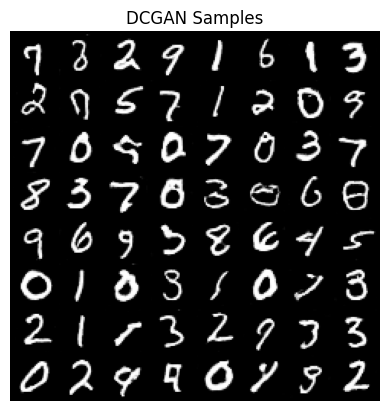

In [13]:
G.eval()

with torch.no_grad():

    z = torch.randn(64, latent_size, 1, 1).to(device)

    samples = G(z)

grid = make_grid(samples, 8, normalize=True)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("DCGAN Samples")
plt.axis("off")
plt.show()


## **🙋 [GAN] Question 1**
VAE와 DCGAN으로 MNIST 이미지를 생성한 결과 VAE는 흐릿한 이미지, DCGAN은 선명한 이미지가 생성된 것을 알 수 있습니다. 그 이유를 VAE와 GAN의 특징과 학습 방식을 포함하여 설명해주세요.

* VAE는 원본 이미지를 잘 압축했다가, 최대한 원본과 똑같이 복원하는 것을 목표로 학습하는 모델입니다. VAE는 생성된 이미지와 실제 이미지 사이의 픽셀 값 차이를 최소화하는 방향으로 학습합니다.오차를 줄여야 하는 VAE 입장에서는, 윤곽선을 특정 위치에 뚜렷하게 그렸다가 원본과 위치가 조금이라도 어긋나면 큰 페널티(Loss)를 받게 됩니다. 따라서 틀릴 위험을 줄이기 위해 여러 가능성의 '중간값(평균)'을 칠해버리는 안전한 선택을 하게 됩니다.
결과: 픽셀들의 값이 평균화되면서 경계선이 뭉개지고, 전반적으로 물 빠진 듯한 흐릿한(Blurry) 이미지가 만들어집니다.
 DCGAN은 생성자(Generator)와 판별자(Discriminator)가 서로 대립하며 경쟁하는 적대적 학습(Adversarial Training)을 사용합니다.판별자는 실제 데이터들의 특징(뚜렷한 선, 대비, 질감 등)을 학습해 진짜와 가짜를 구별합니다. 만약 생성자가 VAE처럼 안전하게 '흐릿한' 이미지를 제출하면, 눈치 빠른 판별자는 단번에 "이건 선명하지 않으니 가짜야!"라고 기각해버립니다. 생성자는 판별자에게 기각당하지 않고 살아남기 위해, 모호한 평균값이 아닌 과감하고 뚜렷한 픽셀 값을 선택하게 됩니다. 그 결과 훨씬 실제 데이터에 가까운 선명하고 뚜렷한(Sharp) 이미지가 생성됩니다.


## **🙋 [GAN] Question 2**
GAN 학습 과정에서 Generator와 Discriminator 중 한쪽이 너무 빨리 강해지면 어떤 문제가 발생할 수 있는지, Mode collapse 또는 Vanishing gradient 개념을 활용하여 설명해주세요.

* 판별자가 생성자보다 압도적으로 빠르게 학습되어 완벽한 감별 능력을 갖추게 되는 상황은 기울기 소실 문제가 발생합니다. 학습 초반에 생성자가 만드는 이미지는 그저 노이즈 덩어리일 확률이 높습니다. 이때 판별자가 진짜와 가짜를 너무 완벽하게(확률 100%와 0%로) 구별해버리면 문제가 발생합니다. 생성자가 학습하려면 판별자로부터 "이 부분을 이렇게 고치면 진짜에 더 가까워질 거야"라는 피드백(Gradient, 기울기)을 받아야 합니다. 하지만 판별자가 너무 단호하게 "이건 0.00001% 확률로 가짜야!"라고만 해버리면, 오차 함수의 기울기가 0에 가깝게 평평해집니다.
반대로 생성자가 판별자를 속이는 '특정 꼼수'를 너무 빨리 발견하고, 판별자가 이를 제때 잡아내지 못할 때는 모드 붕괴 현상이 발생합니다. 실제 데이터에는 다양한 형태가 존재합니다.생성자 입장에서는 판별자를 속이는 것이 유일한 목표입니다. 굳이 그리기 어려운 숫자 8이나 9를 연습할 필요 없이, 이미 판별자가 속아주는 완벽한 숫자 '1'만 무한정 찍어내기 시작합니다. 입력되는 노이즈(z)가 변해도 출력은 똑같은 이미지만 나오는 현상, 즉 데이터의 다양성을 잃어버리고 하나의 형태로 붕괴하는 현상이 일어납니다.


## **Part 3. Diffusion Model (DDPM) 원리 구현**

- **Forward process**: 원본 이미지 $x_0$에 $t$번에 걸쳐 점진적으로 Gaussian noise를 주입하여 $x_t$를 만드는 과정. Closed-form으로 한 번에 임의의 t 시점 노이즈 이미지를 계산할 수 있음
  $$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \epsilon,\quad \epsilon \sim \mathcal{N}(0, I)$$

- **Reverse process**: 노이즈 $x_t$로부터 노이즈 $\epsilon$을 예측하는 신경망(주로 U-Net)을 학습시켜, $x_T$(순수 노이즈)부터 $x_0$까지 역으로 복원

- **손실함수의 단순화**: DDPM 논문의 핵심 기여 중 하나로, 복잡한 분포 비교 대신 신경망이 예측한 노이즈와 실제 주입된 노이즈 사이의 단순 MSE Loss만으로 학습이 가능함
  $$L_{simple} = \mathbb{E}_{t, x_0, \epsilon}\left[\, \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \,\right]$$

이번 파트에서는 **forward process와 손실함수, 노이즈 예측 네트워크의 핵심 구조를 직접 코드로 구현**하며 원리를 이해합니다. 다만 DDPM은 실제로는 대규모 U-Net을 오랜 시간 학습해야 제대로 된 이미지가 나오기 때문에, 짧은 실습 환경(Colab)에서 처음부터 학습시키기엔 한계가 있습니다. 그래서 우리가 구현한 것과 동일한 원리로 학습된 **Hugging Face의 사전학습 MNIST DDPM 모델**을 불러와 실제 reverse process 결과를 확인해봅니다.


In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)


### **Noise Schedule 정의**
$\beta_t$를 선형으로 증가시키며, $\alpha_t = 1-\beta_t$, $\bar{\alpha}_t = \prod_{s=1}^{t}\alpha_s$ 를 미리 계산해둡니다.


In [15]:
T = 1000  # DDPM 논문 기준 총 diffusion step 수

beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)


def forward_diffusion(x0, t):
    """x0(원본 이미지)에 timestep t만큼의 노이즈를 주입해 x_t를 반환"""
    noise = torch.randn_like(x0)

    sqrt_ac = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_omac = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    x_t = sqrt_ac * x0 + sqrt_omac * noise   # 🤔 빈칸을 채워주세요 (forward process 수식)

    return x_t, noise


**✍️ 위에서 채운 `forward_diffusion` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

*  DDPM(Denoising Diffusion Probabilistic Models)의 전향 과정(Forward Process)을 수행합니다.원본 이미지($x_0$)에 특정 타임스텝 $t$에 해당하는 양만큼의 가우시안 노이즈를 주입하여, 노이즈가 섞인 이미지($x_t$)를 생성하는 역할을 합니다.특히, $t=1$부터 순차적으로 노이즈를 더하지 않고 수학적 성질(Reparameterization trick)을 이용해 $t$ 시점의 노이즈 이미지를 한 번의 계산으로 바로 구해내는 것이 핵심입니다.원본 이미지 x0와 동일한 형태(shape)를 갖는 표준 정규 분포(평균 0, 분산 1)의 무작위 노이즈 $\epsilon$을 생성하고,배치(Batch) 차원에 맞춰 텐서 연산(Broadcasting)이 가능하도록 차원을 확장합니다.


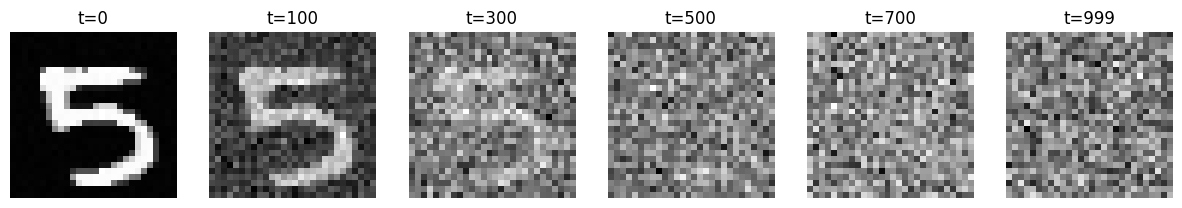

In [16]:
x0, _ = next(iter(train_loader))
x0 = x0[:1].to(device)

timesteps_to_show = [0, 100, 300, 500, 700, 999]
fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))

for i, t_val in enumerate(timesteps_to_show):
    t = torch.tensor([t_val]).to(device)
    x_t, _ = forward_diffusion(x0, t)
    axes[i].imshow(x_t[0, 0].cpu().numpy(), cmap="gray")
    axes[i].set_title(f"t={t_val}")
    axes[i].axis("off")

plt.show()


### **U-Net 기반 노이즈 예측 네트워크**
DDPM은 노이즈가 섞인 이미지 $x_t$와 timestep $t$를 입력받아 주입된 노이즈 $\epsilon$을 예측하는 신경망을 사용합니다. 아래는 skip connection을 포함한 축소된 U-Net 구조입니다. Downsampling에서 저장해둔 feature map을 Upsampling 단계에서 다시 이어붙여(concat), 공간 정보 손실을 줄이는 것이 핵심입니다.


In [17]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb


class SimpleUNet(nn.Module):

    def __init__(self, time_dim=64):
        super().__init__()

        self.time_mlp = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )

        # Downsampling
        self.down1 = nn.Conv2d(1, 64, 3, padding=1)                    # 28 -> 28
        self.down2 = nn.Conv2d(64, 128, 3, stride=2, padding=1)        # 28 -> 14
        self.down3 = nn.Conv2d(128, 256, 3, stride=2, padding=1)       # 14 -> 7

        self.time_proj = nn.Linear(time_dim, 256)

        # Bottleneck
        self.bottleneck = nn.Conv2d(256, 256, 3, padding=1)            # 7 -> 7

        # Upsampling (skip connection으로 채널이 2배가 됨)
        self.up1 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)   # 7 -> 14
        self.up_conv1 = nn.Conv2d(128 + 128, 128, 3, padding=1)           # skip(h2) concat

        self.up2 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)    # 14 -> 28
        self.up_conv2 = nn.Conv2d(64 + 64, 64, 3, padding=1)              # skip(h1) concat

        self.out = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Downsampling (skip connection용으로 각 단계 출력을 저장)
        h1 = F.relu(self.down1(x))      # (B, 64, 28, 28)
        h2 = F.relu(self.down2(h1))     # (B, 128, 14, 14)
        h3 = F.relu(self.down3(h2))     # (B, 256, 7, 7)

        # timestep embedding을 bottleneck 채널에 더해줌
        t_proj = self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h3 = h3 + t_proj   # 🤔 빈칸을 채워주세요 (h3에 timestep 정보를 더해주려면?)

        h3 = F.relu(self.bottleneck(h3))

        # Upsampling + skip connection (concat)
        u1 = F.relu(self.up1(h3))                      # (B, 128, 14, 14)
        u1 = torch.cat([u1, h2], dim=1)                 # (B, 256, 14, 14)
        u1 = F.relu(self.up_conv1(u1))                  # (B, 128, 14, 14)

        u2 = F.relu(self.up2(u1))                       # (B, 64, 28, 28)
        u2 = torch.cat([u2, h1], dim=1)                  # (B, 128, 28, 28)
        u2 = F.relu(self.up_conv2(u2))                   # (B, 64, 28, 28)

        out = self.out(u2)

        return out


**✍️ 위에서 채운 `SimpleUNet.forward`의 timestep 결합 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 모델이 현재 시점 $t$를 인지할 수 있도록, 시간 정보를 담은 임베딩 벡터(t_proj)를 이미지의 특징 맵(Feature Map, h3)에 더해주는 역할을 합니다. 이를 통해 모델은 시간에 조건화되어 각 스텝에 맞는 적절한 노이즈 제거 작업을 수행할 수 있습니다. PyTorch의 브로드캐스팅 규칙에 의해 [B, 256, 1, 1] 크기의 시간 텐서가 [B, 256, 7, 7] 크기에 맞춰 확장되어 모든 픽셀 위치에 동일한 시간 정보가 더해집니다.


### **DDPM Loss**
예측한 노이즈와 실제 주입한 노이즈 사이의 MSE Loss입니다.


In [18]:
def ddpm_loss(model, x0):
    B = x0.size(0)

    t = torch.randint(0, T, (B,), device=device).long()

    x_t, noise = forward_diffusion(x0, t)

    predicted_noise = model(x_t, t)

    loss = F.mse_loss(noise, predicted_noise)   # 🤔 빈칸을 채워주세요 (실제 노이즈 vs 예측 노이즈)

    return loss


**✍️ 위에서 채운 `ddpm_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* ddpm_loss 함수는 디퓨전 모델(DDPM)이 학습할 때 사용하는 손실(Loss) 값을 계산하는 역할을 합니다.디퓨전 모델의 핵심 학습 목표는 "노이즈가 낀 이미지($x_t$)를 보고, 원래 어떤 노이즈($\epsilon$)가 더해졌는지 정확히 예측하는 것"입니다. 따라서 이 함수는 실제로 주입한 노이즈와 모델이 예측한 노이즈 사이의 차이(오차)를 계산하여 모델이 학습할 수 있는 지표를 제공합니다.


## **🙋 [Diffusion] Question 1**
DDPM은 왜 원본 이미지 $x_0$를 직접 예측하지 않고, 이미지에 주입된 노이즈 $\epsilon$을 예측하도록 학습할까요?

* 주입된 노이즈 $\epsilon$은 항상 표준 정규 분포 $\mathcal{N}(0, I)$에서 추출됩니다. 즉, 타겟의 스케일이 모든 타임스텝 $t$에 상관없이 항상 일정하게 유지되므로 모델이 예측하기 훨씬 수월하고 학습이 안정적으로 진행됩니다.

In [19]:
unet = SimpleUNet().to(device)

# 참고: 위에서 구현한 forward_diffusion / SimpleUNet / ddpm_loss가
# DDPM 학습의 핵심 원리 전부입니다. 다만 실제로 눈에 보이는 숫자 이미지를
# 생성할 수준까지 학습시키려면 훨씬 더 큰 모델과 긴 학습 시간이 필요합니다.
# 아래에서는 동일한 원리로 이미 충분히 학습된 사전학습 모델을 불러와
# reverse process 결과를 직접 확인해봅니다.


### **사전학습된 DDPM으로 Reverse Process 결과 확인**

Hugging Face에는 우리가 위에서 구현한 것과 동일한 원리(forward process, 노이즈 예측 U-Net, MSE loss)로 MNIST를 학습시킨 DDPM 모델이 공개되어 있습니다. `DDPMPipeline`을 불러와 실제 reverse process가 어떻게 노이즈에서 숫자 이미지를 만들어내는지 확인해봅시다.


In [20]:
!pip install -q diffusers transformers accelerate safetensors

model_index.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

FrozenDict({'num_train_timesteps': 1000, 'beta_start': 0.0001, 'beta_end': 0.02, 'beta_schedule': 'squaredcos_cap_v2', 'trained_betas': None, 'variance_type': 'fixed_small', 'clip_sample': True, 'prediction_type': 'epsilon', 'thresholding': False, 'dynamic_thresholding_ratio': 0.995, 'clip_sample_range': 1.0, 'sample_max_value': 1.0, 'timestep_spacing': 'leading', 'steps_offset': 0, 'rescale_betas_zero_snr': False, '_class_name': 'DDPMScheduler', '_diffusers_version': '0.27.2'})


  0%|          | 0/200 [00:00<?, ?it/s]

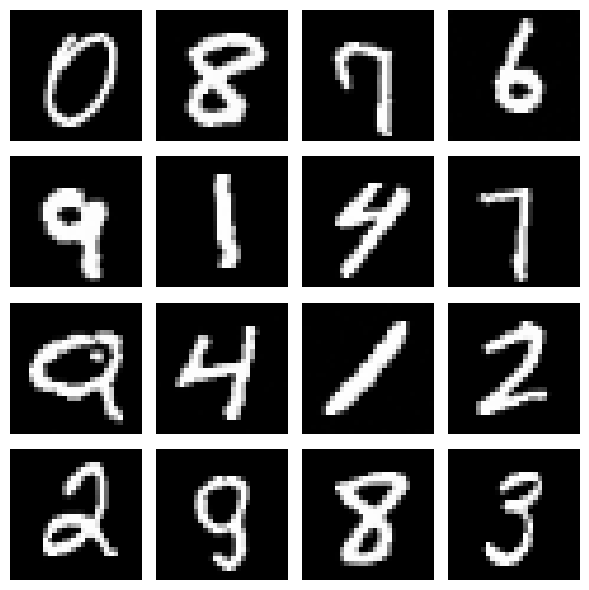

In [21]:
import torch
import matplotlib.pyplot as plt
from diffusers import DDPMPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = DDPMPipeline.from_pretrained(
    "nathanReitinger/MNIST-diffusion"
).to(device)

# Scheduler 설정 확인
print(pipe.scheduler.config)

# Reverse process
images = pipe(
    batch_size=16,
    num_inference_steps=200
).images

# 결과 확인
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for ax, image in zip(axes.flatten(), images):
    ax.imshow(image, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 별도 question!
결과가 이상하게 나와서 당황하셨죠?
왜 ddpm은 앞의 vae와 gan과 다르게 일관적이지 않고 어떤건 바르게 어떤 건 완전 악필이 쓴 것처럼 나오는 걸까요?

DDPM은 100% 완전한 무작위 노이즈($x_T$)에서 출발하여 이미지를 깎아 나갑니다.
문제는 시작점인 이 무작위 노이즈가 모델이 학습했던 데이터의 분포(Manifold)와 너무 동떨어진, 운이 아주 나쁜 형태의 노이즈일 수 있다는 점입니다. 시작 위치가 너무 엉뚱하면, 모델이 아무리 방향을 잘 찾아가려 해도 최종 목적지(예쁜 숫자나 이미지)에 도달하지 못하고 엉뚱한 길에서 헤매다가 '악필' 같은 결과를 내놓게 됩니다.


## **🙋 [Diffusion] Question 2**
VAE, GAN, Diffusion 세 모델을 **학습 안정성**, **생성 품질**, **추론(샘플링) 속도** 세 가지 관점에서 비교해주세요.

앞선 실습 사진을 보고 하는 것이 아닌 이론적으로 비교해주시면 됩니다.아무래도 실습이다보니 이 결과로 비교하는 것은 이론적으로 틀릴 수도 있어서...

1. 학습 안정성 (Training Stability)
VAE와 디퓨전 모델은 학습이 매우 안정적인 반면, GAN은 상당히 불안정합니다. VAE는 수학적으로 명확하게 정의된 오차를 줄이는 방향으로 학습하기 때문에 일반적인 딥러닝 모델처럼 안정적인 수렴이 가능합니다. 디퓨전 모델 역시 정해진 수식에 따라 노이즈를 추가하고 이를 복원하는 과정에서 실제 노이즈와의 오차만 줄이면 되므로 학습이 순조롭습니다. 반면 GAN은 가짜 이미지를 만드는 생성자와 이를 감별하는 판별자가 서로 적대적으로 경쟁하는 구조입니다. 두 네트워크 간의 팽팽한 균형이 조금만 무너져도 학습이 망가지며, 특정 이미지만 계속 반복해서 만들어내는 모드 붕괴(Mode Collapse) 현상에 빠지기 쉬워 튜닝이 매우 까다롭습니다.

2. 생성 품질 (Generation Quality)
생성된 이미지의 선명도와 다양성 측면에서는 디퓨전 모델이 가장 뛰어나며, 그 뒤를 GAN과 VAE가 잇습니다. 디퓨전 모델은 수백 번의 복원 단계를 거쳐 픽셀의 디테일을 정교하게 깎아내기 때문에, 현존하는 모델 중 가장 선명하고 데이터의 다양한 특징을 잘 반영한 최고 품질의 이미지를 만들어냅니다. GAN은 판별자를 완벽하게 속이는 것이 목적이므로 픽셀 단위로 매우 쨍하고 선명한 이미지를 생성하지만, 자신이 잘 만드는 특정 결과물만 편식하려는 경향이 있어 다양성은 다소 떨어질 수 있습니다. 반면 VAE는 원본과의 픽셀 차이를 평균적으로 줄이려는 안전한 선택을 하기 때문에, 결과물이 전체적으로 뭉개지고 흐릿하게(Blurry) 생성되는 뚜렷한 한계가 있습니다.

3. 추론 및 생성 속도 (Inference Speed)
학습이 끝난 모델을 통해 새로운 이미지를 만들어내는 속도는 VAE와 GAN이 압도적으로 빠르고 디퓨전 모델은 매우 느립니다. VAE의 디코더나 GAN의 생성자는 입력된 노이즈를 단 한 번만 통과시키면 즉각적으로 완성된 이미지를 뱉어내므로 실시간 서비스에 유리합니다. 하지만 디퓨전 모델은 완전한 노이즈 상태에서 출발해 수백에서 수천 번에 걸쳐 모델을 반복적으로 거치며 노이즈를 조금씩 걷어내야 합니다. 이 과정 때문에 이미지를 단 한 장 뽑아내는 데 걸리는 시간이 다른 두 모델에 비해 기하급수적으로 깁니다.


## **Part 4. Hugging Face `diffusers`로 사전학습 Diffusion 모델 실습**

Part 3에서 우리는 DDPM의 핵심 원리(forward process, 노이즈 예측 U-Net, MSE loss)를 직접 코드로 구현하고, MNIST 전용 사전학습 모델로 그 결과를 확인해봤습니다. 이번에는 훨씬 크고 복잡한 U-Net을 방대한 이미지-텍스트 데이터로 학습시킨 모델을 다뤄봅니다. 대표적으로 **Stable Diffusion**은 발표자료에서 다룬 것처럼 VAE + Diffusion(Latent Diffusion) + Cross-Attention 기반 Text Conditioning 구조를 가지고 있습니다.

Hugging Face의 `diffusers` 라이브러리를 사용하면 이런 사전학습 모델을 몇 줄의 코드로 불러와 사용할 수 있습니다. Colab에서는 **런타임 유형을 GPU로 설정**한 후 진행해주세요. (런타임 → 런타임 유형 변경 → T4 GPU)


In [22]:
!pip install -q diffusers transformers accelerate


### **4-1. Text-to-Image: Stable Diffusion**

프롬프트를 입력하면 그에 맞는 이미지를 생성해주는 `StableDiffusionPipeline`을 사용해봅니다. 내부적으로는 텍스트 프롬프트를 CLIP text encoder로 임베딩하고, 이를 조건으로 latent space에서 diffusion(denoising)을 수행한 뒤, VAE decoder로 pixel space 이미지를 복원합니다. (발표자료 33p의 Stable Diffusion 구조 참고)


In [23]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

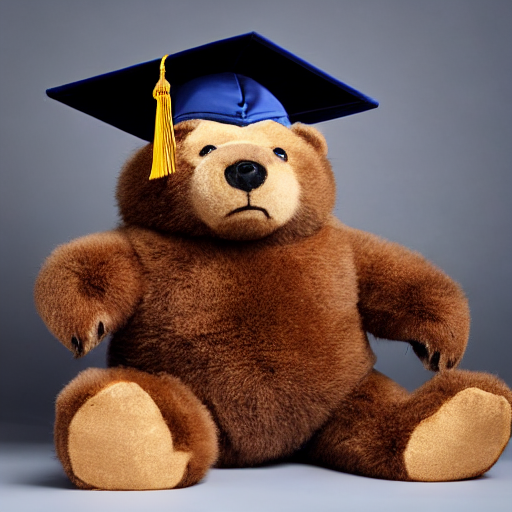

In [28]:
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"

image = pipe(
    prompt,
    num_inference_steps=50,  # 💡 빈칸 정답: 보통 20 ~ 50 사이의 값을 많이 사용합니다!
    guidance_scale=7.5
).images[0]

image

**✍️ 위에서 채운 `num_inference_steps` 코드가 어떤 기능을 하고, 이 값이 커지거나 작아지면 결과가 어떻게 달라지는지 간단히 설명해주세요.**

* 디퓨전 모델이 100% 무작위 노이즈 상태에서 시작해, 노이즈를 깎아내고(Denoising) 이미지를 다듬는 과정을 총 몇 번 반복할 것인지 결정하는 파라미터입니다.값이 커지면 모델이 더 정교하고 세밀하게 노이즈를 다듬기 때문에 이미지의 디테일과 퀄리티가 높아집니다. 다만, 반복 횟수가 늘어나므로 이미지를 생성하는 데 시간이 훨씬 오래 걸립니다. 작아지면 노이즈 제거를 빠르게 끝내버리기 때문에 생성 속도는 매우 빠릅니다. 하지만 노이즈가 미처 다 지워지지 않아 형태가 뭉개지거나, 덜 완성된 듯한 흐릿한 저품질 이미지가 나옵니다.

## **🙋 [Hugging Face] Question 1**
위 코드의 `guidance_scale` 파라미터는 발표자료의 **Classifier-free guidance(CFG)** 개념과 관련이 있습니다. `guidance_scale` 값을 낮추거나(예: 1.0) 높이면(예: 15.0) 생성 결과가 각각 어떻게 달라질지 예상해보고, 실제로 두 값으로 각각 이미지를 생성해 비교해주세요.

* 이미지 자체는 자연스러울 수 있으나, 명령어 누락 현상이 심하게 발생합니다. 너무 높으면 색상 대비(Contrast)가 비정상적으로 극단화되고, 질감이 뭉개지거나, 채도가 눈이 아플 정도로 높아지는 등 인위적인 불쾌감(Artifact)이 뚜렷하게 나타납니다.


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

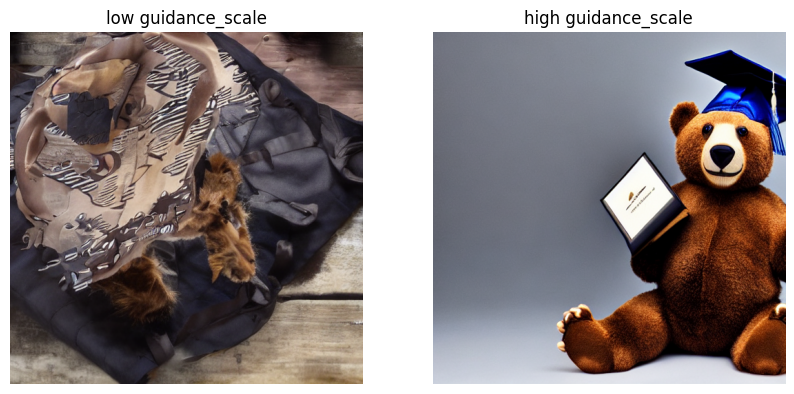

In [32]:
# 🤔 guidance_scale을 다르게 주어 두 이미지를 생성하고 비교해주세요
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"

image_low_cfg = pipe(prompt, num_inference_steps=30, guidance_scale= 1).images[0]   # 🤔 빈칸을 채워주세요
image_high_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=10).images[0]  # 🤔 빈칸을 채워주세요

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_low_cfg)
axes[0].set_title("low guidance_scale")
axes[0].axis("off")
axes[1].imshow(image_high_cfg)
axes[1].set_title("high guidance_scale")
axes[1].axis("off")
plt.show()


**✍️ 위에서 채운 `guidance_scale` 비교 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 동일한 텍스트 프롬프트(명령어)를 입력했을 때, guidance_scale 값의 변화에 따라 모델이 명령어를 따르는 강도와 생성되는 이미지의 품질이 어떻게 달라지는지 한눈에 시각적으로 비교하기 위한 코드입니다.


### **4-2. Sampler(Scheduler) 교체해보기**

발표자료 33p에서 언급했듯 Stable Diffusion은 하나로 고정된 모델이 아니라, denoising에 사용하는 sampler(scheduler)를 자유롭게 교체할 수 있는 구조입니다. 기본 스케줄러 대신 DDIM 스케줄러로 교체하여 더 적은 step으로도 이미지를 생성해봅니다.


  0%|          | 0/20 [00:00<?, ?it/s]

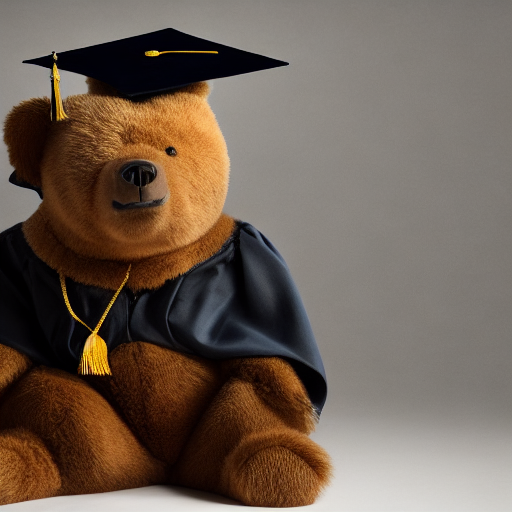

In [33]:
from diffusers import DDIMScheduler

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

image_ddim = pipe(
    prompt,
    num_inference_steps=20,  # DDPM보다 훨씬 적은 step
    guidance_scale=7.5
).images[0]

image_ddim


## **🙋 [Hugging Face] Question 2**
DDIM 스케줄러가 기본 스케줄러보다 적은 step으로도 그럴듯한 이미지를 생성할 수 있는 이유를 Part 3에서 다룬 DDPM의 reverse process와 비교하여 설명해주세요.

* DDIM(Denoising Diffusion Implicit Models) 스케줄러가 DDPM보다 훨씬 적은 스텝(Step)으로도 고품질의 이미지를 생성할 수 있는 핵심적인 이유는 '마르코프 체인(Markov Chain)' 가정을 깼기 때문입니다.  DDPM의 Reverse Process는 마르코프 체인 가정을 따릅니다. 즉, $t-1$ 시점의 이미지를 복원하기 위해서는 반드시 바로 직전 시점인 $t$의 정보가 필요합니다. 학습할 때 노이즈를 1000번에 걸쳐 쪼개서 넣었다면, 복원할 때도 $1000 \rightarrow 999 \rightarrow 998 \dots \rightarrow 0$처럼 1000개의 계단을 하나하나 순차적으로 다 밟고 내려와야만 합니다. 중간에 계단을 건너뛰면 수학적 연결 고리가 끊어져 이미지가 망가집니다.  DDIM 논문의 저자들은 DDPM의 수식을 영리하게 비틀어, 노이즈를 제거하는 과정을 확률적인 성격에서 결정론적(Deterministic)인 성격으로 바꿨습니다.DDIM은 매 스텝마다 $x_t$에서 노이즈를 찔끔 빼서 $x_{t-1}$을 만드는 것이 아닙니다. 현재 상태 $x_t$와 예측된 노이즈를 이용해 "최종 완성본인 $x_0$가 대충 어떻게 생겼을지"를 한 번에 예측한 다음, 거꾸로 우리가 이동하고 싶은 목표 시점(예: $t-20$)에 맞춰 노이즈를 다시 씌우는 방식을 취합니다.

## **🙋 [Hugging Face] Question 3**
직접 해보기 + 허깅 페이스와 인사하기

허깅페이스의 모델 api 활용하기/space에서 모델 3개 이상 활용해보기
둘 중 하나를 택해서 실행하고 간단하게 써본 경험을 공유해주세요!

[예시 노션 링크](https://app.notion.com/p/Hugging-face-3a059e60d52d80f49489f7a3c3ef6648?source=copy_link)


SDXL, 코드를 작성할 필요 없이 직관적인 UI(Gradio)에 텍스트만 입력했는데, 불과 몇 초 만에 압도적인 퀄리티의 이미지가 생성되어 놀라웠습니다. 특히 빛의 반사나 네온사인의 디테일이 이전 버전 모델들보다 훨씬 정교해졌음을 체감할 수 있었습니다.

Illusion Diffusion, 나선형 패턴을 입력 조건으로 주었더니, 마을의 지붕과 길의 배치가 절묘하게 나선형을 이루도록 풍경이 생성되었습니다. 디퓨전 모델에 '조건(Conditioning)'을 부여하는 ControlNet의 위력을 시각적으로 가장 재밌게 확인할 수 있었습니다.

MusicGen, 텍스트 프롬프트를 입력하고 잠시 기다리니, 정말 유튜브에서 흔히 듣던 그럴듯한 15초짜리 로파이(Lo-fi) 코딩 비트가 뚝딱 만들어졌습니다. 멀티모달(Multi-modal) AI의 놀라운 확장성을 귀로 직접 경험한 순간이었습니다.



## 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): 디버깅, 개념 설명

- **AI가 이 실험에는 틀린 답을 준 사례** —
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: (여기에 답)

- **실제 대화 내역** 붙여넣기:

```
시진 전송 후 왜 그런 결과가 나오는지 물었습니다.
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? 숫자 조절입니다.
